# Avance 5: Modelo Final

- **Holt-Winters** (baseline) y un **ajuste** de desface de vcunas


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import warnings, numpy as np, pandas as pd
warnings.filterwarnings("ignore")

DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/Proyecto integrador/Avance 5/dataset_sarampion_vacunas_2010-2023.csv"

df = pd.read_csv(DATA_PATH)
df.head(), df.shape


(   mes  anio  total_dosis  casos_sarampion
 0    1  2010       180830                0
 1    2  2010       183377                0
 2    3  2010       242572                0
 3    4  2010       216429                0
 4    5  2010       174559                0,
 (168, 4))

In [ ]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from itertools import product

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

from statsmodels.tsa.holtwinters import ExponentialSmoothing

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
np.seterr(divide="ignore", invalid="ignore")
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 100

SPLIT_YEAR = 2019
TRAIN_START_YEAR = 2010
TRAIN_END_YEAR = 2018
TEST_START_YEAR = 2019
TEST_END_YEAR = 2023

DESFASE_VACUNAS = 2

FORZAR_GRID_SEARCH = False
CACHE_DIR = Path("cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

BEST_CONFIG_PATH = CACHE_DIR / f"holtwinters_best_config_desfase_{DESFASE_VACUNAS}m.json"

def smape(y_true, y_pred):

    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred)
    denom = np.where(denom == 0, 1.0, denom)
    return float(100.0 * np.mean(np.abs(y_true - y_pred) / denom))

print("✓ Librerías cargadas correctamente (Holt-Winters)")
print(f"✓ Período de entrenamiento: {TRAIN_START_YEAR}-{TRAIN_END_YEAR}")
print(f"✓ Período de prueba: {TEST_START_YEAR}-{TEST_END_YEAR}")
print(f"✓ Desfase único de vacunación: {DESFASE_VACUNAS} meses")
print(f"✓ Cache de parámetros: {BEST_CONFIG_PATH}")
print(f"✓ Forzar grid search: {FORZAR_GRID_SEARCH}")

✓ Librerías cargadas correctamente (Holt-Winters)
✓ Período de entrenamiento: 2010-2018
✓ Período de prueba: 2019-2023
✓ Desfase único de vacunación: 2 meses
✓ Cache de parámetros: cache/holtwinters_best_config_desfase_2m.json
✓ Forzar grid search: False


In [ ]:
base_path = "/content/drive/MyDrive/Colab Notebooks/Proyecto integrador/Avance 5"

# ── 2.1 Dataset de Features Engineered ──
df_fe = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Proyecto integrador/Avance 5/dataset_sarampion_features_engineered.csv")
df_fe["fecha"] = pd.to_datetime(df_fe["fecha"])
df_fe = df_fe.sort_values("fecha").reset_index(drop=True)

# ── 2.2 Dataset de Vacunación ──
df_vacunas = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Proyecto integrador/Avance 5/dataset_sarampion_vacunas_2010-2023.csv")
df_vacunas["fecha"] = pd.to_datetime(
    df_vacunas["anio"].astype(str) + "-" + df_vacunas["mes"].astype(str) + "-01"
)
df_vacunas = df_vacunas.sort_values("fecha").reset_index(drop=True)

# Variable binaria de brote
df_fe["brote"] = (df_fe["casos_sarampion"] > 0).astype(int)
df_vacunas["brote"] = (df_vacunas["casos_sarampion"] > 0).astype(int)

print(f"✓ df_fe cargado: {df_fe.shape}")
print(f"✓ df_vacunas cargado: {df_vacunas.shape}")
print(f"  Período df_fe: {df_fe['fecha'].min().date()} → {df_fe['fecha'].max().date()}")
print(f"  Período vacunas: {df_vacunas['fecha'].min().date()} → {df_vacunas['fecha'].max().date()}")

✓ df_fe cargado: (154, 32)
✓ df_vacunas cargado: (168, 6)
  Período df_fe: 2011-03-01 → 2023-12-01
  Período vacunas: 2010-01-01 → 2023-12-01


In [ ]:
df_vacunas.head()

,mes,anio,total_dosis,casos_sarampion,fecha,brote
0,1,2010,180830,0,2010-01-01,0
1,2,2010,183377,0,2010-02-01,0
2,3,2010,242572,0,2010-03-01,0
3,4,2010,216429,0,2010-04-01,0
4,5,2010,174559,0,2010-05-01,0


##Dataset del modelo (solo y + vacunas con lag)

In [ ]:
VAC_COL = "total_dosis" if "total_dosis" in df_vacunas.columns else None
if VAC_COL is None:
    cand = [c for c in df_vacunas.columns
            if c not in ["anio", "mes", "fecha", "casos_sarampion", "brote"]
            and pd.api.types.is_numeric_dtype(df_vacunas[c])]
    if len(cand) == 0:
        raise ValueError("No encontré columna de vacunas. Define VAC_COL manualmente.")
    VAC_COL = cand[0]
    print(f"VAC_COL detectada automáticamente: {VAC_COL}")

df_model = df_vacunas[["fecha", "casos_sarampion", VAC_COL]].copy()
df_model = df_model.sort_values("fecha").reset_index(drop=True)

df_model.rename(columns={
    "fecha": "ds",
    "casos_sarampion": "y",
    VAC_COL: "vacunas_raw"
}, inplace=True)

df_model["vacunas"] = df_model["vacunas_raw"].shift(DESFASE_VACUNAS)

df_model["vacunas"] = df_model["vacunas"].fillna(0)

df_model["y"] = df_model["y"].clip(lower=0)
df_model["vacunas"] = df_model["vacunas"].clip(lower=0)

print("✓ df_model listo:", df_model.shape)
display(df_model.head())
display(df_model.tail())

✓ df_model listo: (168, 4)


,ds,y,vacunas_raw,vacunas
0,2010-01-01,0,180830,0.0
1,2010-02-01,0,183377,0.0
2,2010-03-01,0,242572,180830.0
3,2010-04-01,0,216429,183377.0
4,2010-05-01,0,174559,242572.0


,ds,y,vacunas_raw,vacunas
163,2023-08-01,0,190148,323897.0
164,2023-09-01,0,322586,319238.0
165,2023-10-01,0,365603,190148.0
166,2023-11-01,0,316722,322586.0
167,2023-12-01,0,215309,365603.0


##Split Train/Test

In [ ]:
df_train = df_model[
    (df_model["ds"].dt.year >= TRAIN_START_YEAR) &
    (df_model["ds"].dt.year <= TRAIN_END_YEAR)
].copy()

df_test = df_model[
    (df_model["ds"].dt.year >= TEST_START_YEAR) &
    (df_model["ds"].dt.year <= TEST_END_YEAR)
].copy()

df_train = df_train.sort_values("ds").reset_index(drop=True)
df_test = df_test.sort_values("ds").reset_index(drop=True)

print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)

print("Train:", df_train["ds"].min(), "→", df_train["ds"].max())
print("Test :", df_test["ds"].min(), "→", df_test["ds"].max())

Train shape: (108, 4)
Test shape: (60, 4)
Train: 2010-01-01 00:00:00 → 2018-12-01 00:00:00
Test : 2019-01-01 00:00:00 → 2023-12-01 00:00:00


##Métricas

In [ ]:
def evaluar_metricas(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    s = smape(y_true, y_pred)

    return {
        "mae": float(mae),
        "rmse": float(rmse),
        "smape": float(s)
    }

##Ya que holt winters no admite valiables exógenas directamente, se aplica un modelo de regresión, utilizando ExponentialSmoothing

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing


def fit_regression_with_intercept(x, y):

    x = np.asarray(x).reshape(-1,1)
    y = np.asarray(y).reshape(-1,1)

    X = np.hstack([np.ones((len(x),1)), x])

    beta, *_ = np.linalg.lstsq(X, y, rcond=None)

    b0 = float(beta[0,0])
    b1 = float(beta[1,0])

    return b0, b1


def predict_regression(b0, b1, x):

    x = np.asarray(x)

    return b0 + b1 * x


def hw_exog_fit_forecast(df_tr, df_future, params):

    y_tr = df_tr["y"].values
    x_tr = df_tr["vacunas"].values

    b0, b1 = fit_regression_with_intercept(x_tr, y_tr)

    y_reg = predict_regression(b0, b1, x_tr)

    resid = y_tr - y_reg

    model = ExponentialSmoothing(
        resid,
        trend=params["trend"],
        damped_trend=params["damped_trend"],
        seasonal=params["seasonal"],
        seasonal_periods=params["seasonal_periods"],
        initialization_method="estimated"
    )

    fit = model.fit(
        smoothing_level=params["alpha"],
        smoothing_trend=params["beta"],
        smoothing_seasonal=params["gamma"],
        optimized=False
    )

    h = len(df_future)

    resid_fore = fit.forecast(h)

    y_reg_future = predict_regression(b0, b1, df_future["vacunas"].values)

    y_pred = y_reg_future + resid_fore

    y_pred = np.clip(y_pred, 0, None)

    return {
        "b0": b0,
        "b1": b1,
        "fit_resid": fit,
        "y_pred": y_pred
    }

##Utilizando Time series para una validación temporal

In [ ]:
def cv_hw_time_series(df_train, params, n_splits=4):

    tscv = TimeSeriesSplit(n_splits=n_splits)

    metrics = []

    for tr_idx, val_idx in tscv.split(df_train):

        tr = df_train.iloc[tr_idx].copy()
        val = df_train.iloc[val_idx].copy()

        out = hw_exog_fit_forecast(tr, val, params)

        m = evaluar_metricas(val["y"].values, out["y_pred"])

        metrics.append(m)

    return {
        "mae": np.mean([m["mae"] for m in metrics]),
        "rmse": np.mean([m["rmse"] for m in metrics]),
        "smape": np.mean([m["smape"] for m in metrics])
    }

##Grid de Hiperparámetros para Holtwinters

In [ ]:
param_grid = {
    "alpha":[0.2,0.4,0.6,0.8],
    "beta":[0.0,0.1,0.2],
    "gamma":[0.0,0.1,0.2],
    "trend":[None,"add"],
    "damped_trend":[False,True],
    "seasonal":[None,"add"],
    "seasonal_periods":[12]
}

grid = []

for a,b,g,t,d,s,sp in product(
    param_grid["alpha"],
    param_grid["beta"],
    param_grid["gamma"],
    param_grid["trend"],
    param_grid["damped_trend"],
    param_grid["seasonal"],
    param_grid["seasonal_periods"]
):

    params = {
        "alpha":a,
        "beta":None if t is None else b,
        "gamma":None if s is None else g,
        "trend":t,
        "damped_trend":False if t is None else d,
        "seasonal":s,
        "seasonal_periods":None if s is None else sp
    }

    grid.append(params)

print("Total combinaciones:", len(grid))

Total combinaciones: 288


##Grid Search para el mejor hiperparámetro

In [ ]:
best = {"rmse":np.inf, "params":None}

rows = []

for i,params in enumerate(grid):

    try:

        avg = cv_hw_time_series(df_train, params)

        rows.append({
            **params,
            "rmse":avg["rmse"],
            "mae":avg["mae"],
            "smape":avg["smape"]
        })

        if avg["rmse"] < best["rmse"]:

            best["rmse"] = avg["rmse"]
            best["params"] = params

        if i % 20 == 0:

            print(i,"/",len(grid),"mejor RMSE:",best["rmse"])

    except:
        pass


df_results = pd.DataFrame(rows).sort_values("rmse")

display(df_results.head(10))

print("Mejor configuración:",best)

0 / 288 mejor RMSE: 3.088861481716183
20 / 288 mejor RMSE: 3.088861481716183
40 / 288 mejor RMSE: 2.9432059360251284
60 / 288 mejor RMSE: 2.752798617656141
80 / 288 mejor RMSE: 2.752798617656141
100 / 288 mejor RMSE: 2.752798617656141
120 / 288 mejor RMSE: 2.752798617656141
140 / 288 mejor RMSE: 2.637798085489787
160 / 288 mejor RMSE: 2.637798085489787
180 / 288 mejor RMSE: 2.637798085489787
200 / 288 mejor RMSE: 2.515766576278886
220 / 288 mejor RMSE: 2.515766576278886
240 / 288 mejor RMSE: 2.515766576278886
260 / 288 mejor RMSE: 2.515766576278886
280 / 288 mejor RMSE: 2.434181809187601


,alpha,beta,gamma,trend,damped_trend,seasonal,seasonal_periods,rmse,mae,smape
214,0.8,0.2,NaN,add,False,None,NaN,2.434182,0.543527,8.333333
202,0.8,0.2,NaN,add,False,None,NaN,2.434182,0.543527,8.333333
208,0.8,0.2,NaN,add,False,None,NaN,2.434182,0.543527,8.333333
154,0.6,0.2,NaN,add,False,None,NaN,2.515767,0.601017,21.428571
148,0.6,0.2,NaN,add,False,None,NaN,2.515767,0.601017,21.428571
160,0.6,0.2,NaN,add,False,None,NaN,2.515767,0.601017,21.428571
170,0.8,NaN,NaN,None,False,None,NaN,2.621512,0.748564,60.613222
182,0.8,NaN,NaN,None,False,None,NaN,2.621512,0.748564,60.613222
210,0.8,NaN,NaN,None,False,None,NaN,2.621512,0.748564,60.613222
212,0.8,NaN,NaN,None,False,None,NaN,2.621512,0.748564,60.613222


Mejor configuración: {'rmse': np.float64(2.434181809187601), 'params': {'alpha': 0.8, 'beta': 0.2, 'gamma': None, 'trend': 'add', 'damped_trend': False, 'seasonal': None, 'seasonal_periods': None}}


##**Entrenamiento con mejor hiperparámetro**

In [ ]:
params_final = best["params"]

out_test = hw_exog_fit_forecast(df_train, df_test, params_final)

yhat_test = out_test["y_pred"]

metrics_test = evaluar_metricas(df_test["y"].values, yhat_test)

print("RESULTADOS TEST")
print(metrics_test)

RESULTADOS TEST
{'mae': 6.400448502491465, 'rmse': 14.428765692330444, 'smape': 91.82852013247039}


**Interpretación de las métricas (Test)**

- **MAE = 6.40**

En promedio, el modelo se equivoca ≈ 6.4 casos de sarampión por mes respecto al valor real.

- **RMSE = 14.43**

El error cuadrático medio es mayor que el MAE, lo que indica que existen algunos meses con errores más grandes que influyen en la métrica.

- **SMAPE = 91.83%**

El error porcentual es muy alto, lo que sugiere que el modelo no está capturando bien la dinámica de los casos.

##**Gráfica de predicción vs observado**

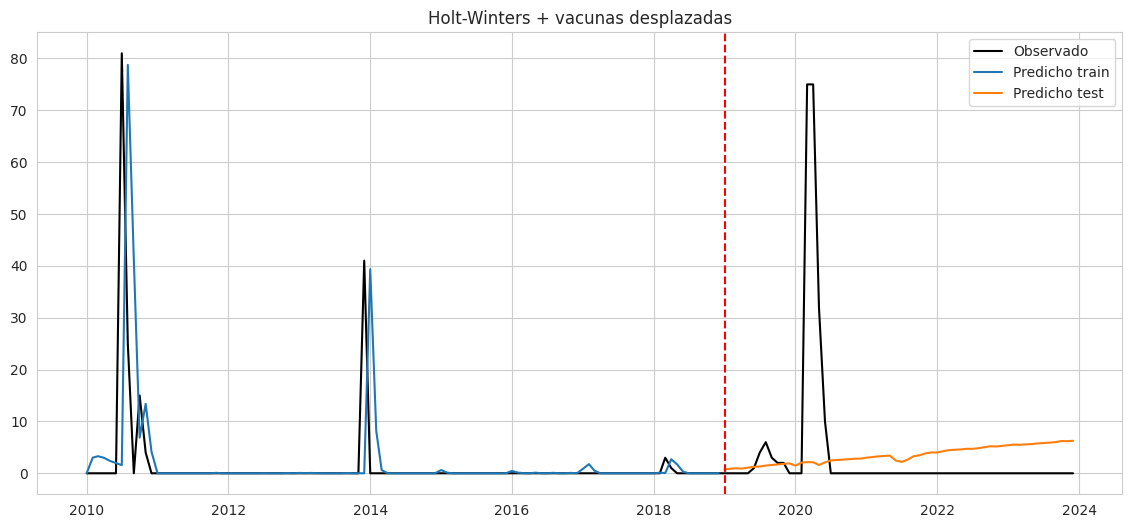

In [ ]:
y_train = df_train["y"].values
x_train = df_train["vacunas"].values

b0 = out_test["b0"]
b1 = out_test["b1"]

y_reg_train = predict_regression(b0,b1,x_train)

fit_resid = out_test["fit_resid"]

resid_fit = fit_resid.fittedvalues

yhat_train = np.clip(y_reg_train + resid_fit,0,None)

df_plot = pd.concat([
    df_train.assign(split="train",yhat=yhat_train),
    df_test.assign(split="test",yhat=yhat_test)
])

plt.figure(figsize=(14,6))

plt.plot(df_plot["ds"],df_plot["y"],"k-",label="Observado")

plt.plot(
    df_plot[df_plot["split"]=="train"]["ds"],
    df_plot[df_plot["split"]=="train"]["yhat"],
    label="Predicho train"
)

plt.plot(
    df_plot[df_plot["split"]=="test"]["ds"],
    df_plot[df_plot["split"]=="test"]["yhat"],
    label="Predicho test"
)

plt.axvline(df_test["ds"].min(),color="red",linestyle="--")

plt.title("Holt-Winters + vacunas desplazadas")

plt.legend()

plt.show()

**Comportamiento general del modelo**

Holt-Winters produce predicciones suaves y graduales, lo cual es adecuado para series con tendencia o estacionalidad estable.

Sin embargo, los brotes epidemiológicos son eventos abruptos, por lo que el modelo no captura bien esos cambios repentinos.

**Interpretación de la gráfica**

La gráfica muestra que el modelo ajusta razonablemente los datos históricos, pero no logra predecir brotes repentinos en el periodo de prueba, generando predicciones más suaves que los valores reales. Esto sugiere que, aunque el modelo captura la tendencia general, no es suficientemente sensible para detectar eventos epidemiológicos extremos como los brotes de sarampión.

##**Conclusión**

El modelo **Holt-Winters con vacunas desplazadas como variable exógena**permitió capturar parcialmente la tendencia general de la serie histórica de casos de sarampión durante el periodo de entrenamiento. Sin embargo, debido a que la serie presenta **muchos valores cercanos a cero y picos abruptos asociados a brotes epidemiológicos**, el modelo tiende a generar **predicciones suavizadas**, lo que limita su capacidad para anticipar aumentos repentinos en los casos.

En el periodo de prueba, el modelo mantuvo predicciones bajas y graduales, sin lograr reproducir adecuadamente el brote observado alrededor de 2020. Esto se refleja en el **alto error porcentual (SMAPE)** y en la diferencia entre los valores observados y predichos en los picos de la serie.

En general, aunque Holt-Winters es útil para modelar **tendencias y patrones estacionales en series relativamente estables**, su desempeño es limitado para este problema, ya que los **brotes epidemiológicos presentan comportamientos irregulares y discontinuos** que requieren modelos más flexibles o la incorporación de **más variables explicativas** para mejorar la capacidad de pronóstico.